In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from scipy.stats import wilcoxon


In [2]:
df_times = pd.read_csv("TimesNet_TSB-AD-U_results_mean_short.csv")
df_fed = pd.read_csv("FEDFormer_TSB-AD-U_results_mean_short.csv")
df_auto = pd.read_csv("Autoformer_TSB-AD-U_results_mean_short.csv")
df_mixer = pd.read_csv("TimeMixer_TSB-AD-U_results_mean_short.csv")
df_trans = pd.read_csv("Transformer_TSB-AD-U_results_mean_short.csv")
df_itrans = pd.read_csv("iTransformer_TSB-AD-U_results_mean_short.csv")
df_dlinear = pd.read_csv("DLinear_TSB-AD-U_results_mean_short.csv")
df_pyraformer = pd.read_csv("Pyraformer_TSB-AD-U_results_mean_short.csv")
df_crossformer = pd.read_csv("Crossformer_TSB-AD-U_results_mean_short.csv")
df_autoencoder = pd.read_csv("AutoEncoder_TSB-AD-U_results_mean_short.csv")
df_linear = pd.read_csv("Linear_TSB-AD-U_results_mean_short.csv")




models = {
    "DLinear": df_dlinear,
    "TimesNet": df_times,
    "iTransformer": df_itrans,
    "Linear": df_linear,
    "AutoEncoder": df_autoencoder,
    "Crossformer": df_crossformer,
    "Transformer": df_trans,
    "Pyraformer": df_pyraformer,
    "FEDFormer": df_fed,
    "AutoFormer": df_auto,
    "TimeMixer": df_mixer,
}

first_model = next(iter(models))
filenames = models[first_model]["filename"].tolist()

# Build matrix of AUC-PR values
data = []
model_names = []

for model_name, df in models.items():
    # align on filename, just in case order differs
    s = (
        df.set_index("filename")["AUC-PR"]
          .reindex(filenames)          # ensures same order
    )
    data.append(s.values)
    model_names.append(model_name)

data = np.array(data)   # shape: (n_models, n_files)
n_models, n_files = data.shape


FileNotFoundError: [Errno 2] No such file or directory: 'TimesNet_TSB-AD-U_results_mean_short.csv'

/tmp/ipykernel_8460/3034917515.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap('viridis')


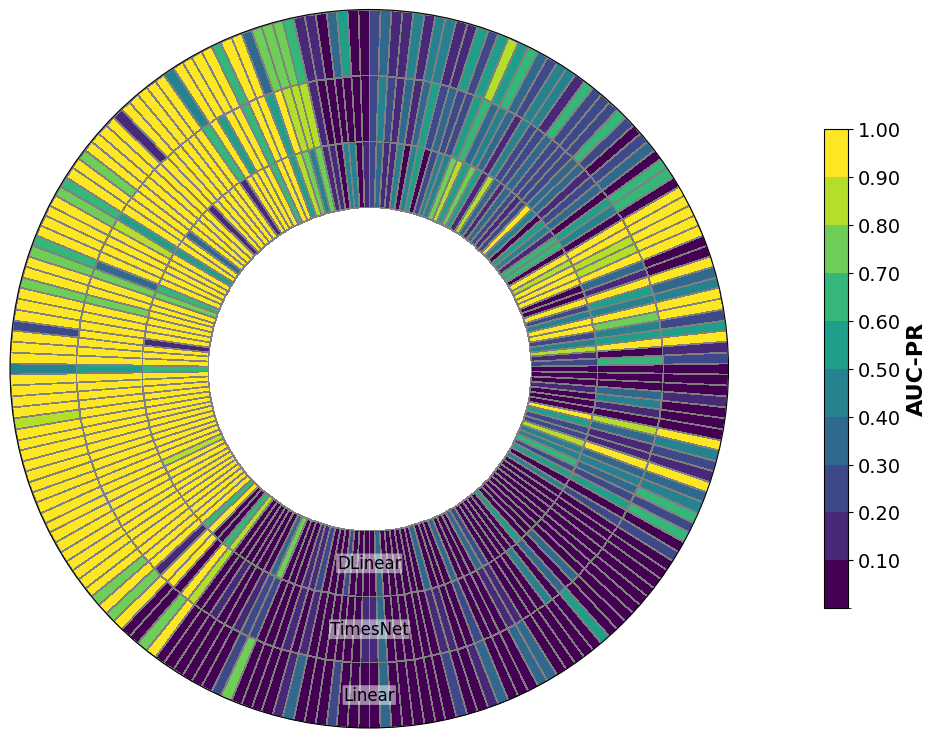

In [5]:
# ------------------------------
# 2. Define Plotting Parameters
# ------------------------------
center_radius = 0.25      # radius of the empty hole
inner_heatmap_radius = 0.45  # where the first ring starts
outer_heatmap_radius = 1.0    # outer boundary

# radii for rings
r = np.linspace(inner_heatmap_radius, outer_heatmap_radius, n_models + 1)
theta = np.linspace(0, 2*np.pi, n_files + 1)

R, Theta = np.meshgrid(r, theta)

# ------------------------------
# 3. Define Discrete Colormap and Norm
# ------------------------------
N_LEVELS = 10
V_MIN, V_MAX = 0.0, 1.0
base_cmap = plt.cm.get_cmap('viridis')
cmap_colors = base_cmap(np.linspace(0, 1, N_LEVELS))
cmap = colors.ListedColormap(cmap_colors)

bounds = np.linspace(V_MIN, V_MAX, N_LEVELS + 1)
norm = colors.BoundaryNorm(bounds, cmap.N)

cbar_ticks = bounds[:-1] + (bounds[1] - bounds[0])# / 2

# ------------------------------
# 4. Plot
# ------------------------------
plt.rcParams.update({'font.size': 14})
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection="polar")
ax.grid(False)
pc = ax.pcolormesh(
    Theta, R, data.T,
    shading="auto",
    cmap=cmap,
    norm=norm,
    edgecolor='grey', # ADDED: Grey edges
    linewidth=0.5,    # ADDED: Edge linewidth
    rasterized=True
)

# ------------------------------
# 5. Colorbar
# ------------------------------
cbar = plt.colorbar(
    pc,
    ax=ax,
    pad=0.1,
    orientation="vertical",
    ticks=cbar_ticks,
    boundaries=bounds,
    shrink=0.5
)

cbar.set_ticklabels([f'{t:.2f}' for t in cbar_ticks])
cbar.set_label("AUC-PR", fontsize=16, weight='bold')

# ------------------------------
# 6. Aesthetic Touches
# ------------------------------
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi/2)
ax.set_xticklabels([])
ax.set_yticklabels([])

ax.set_ylim(0, outer_heatmap_radius)


# Add Model Names (Radial Labels)
ring_centers = (r[:-1] + r[1:]) / 2
label_pos_r = ring_centers
label_angle = np.pi #np.pi/2 + 0.15 # Offset slightly from the top vertical line

for i, name in enumerate(model_names):
    ax.text(label_angle, label_pos_r[i], name,
            ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.05'),
            zorder=12,
            fontsize=12,
            rotation=0#-90
           )


plt.tight_layout()
plt.savefig("polar_heatmap.png")

In [5]:
mean_table = pd.DataFrame({name: df.mean(numeric_only=True) for name, df in models.items()})

# Transpose  models -> rows
mean_table = mean_table.T

print((mean_table*100).round(1).sort_values(by=['AUC-PR'], ascending=False))

          AUC-PR  AUC-ROC  Standard-F1
TimesNet    49.1     82.1         52.0
DLinear     48.7     81.0         52.1
Linear      48.1     80.8         51.6


In [3]:
models = ["TimesNet", "FEDFormer", "Autoformer", "AutoEncoder", "TimeMixer", "Transformer", "iTransformer", "DLinear", "Linear", "Pyraformer", "Crossformer"]


for model in models:
    df_mean = pd.read_csv(f"{model}_TSB-AD-U_results_mean_short.csv")
    df_disj = pd.read_csv(f"{model}_TSB-AD-U_results_disjoint_short.csv")

    X1 = df_mean['AUC-PR'].values * 100
    X2 = df_disj['AUC-PR'].values * 100


    statistic, p_value = wilcoxon(X1, X2, alternative='greater')

    print(f"Model: {model}")
    print(f"P-value  : {p_value:.1e}")

    print(f"Median difference: {np.median(X1 - X2):.1f}")
    print(f"Mean difference: {np.mean(X1 - X2):.1f}")
    print("-"*40)


FileNotFoundError: [Errno 2] No such file or directory: 'TimesNet_TSB-AD-U_results_mean_short.csv'

In [48]:
model = "TimesNet"
seeds = range(1, 6)

for seed in seeds:
    df_mean = pd.read_csv(f"{model}_TSB-AD-U_results_mean_short_{seed}.csv")
    df_disj = pd.read_csv(f"{model}_TSB-AD-U_results_disjoint_short_{seed}.csv")

    X1 = df_mean['AUC-PR'].values * 100
    X2 = df_disj['AUC-PR'].values * 100


    statistic, p_value = wilcoxon(X1, X2, alternative='greater')

    print(f"Seed: {seed}")
    print(f"P-value  : {p_value:.1e}")

    print(f"Median difference: {np.median(X1 - X2):.1f}")
    print(f"Mean difference: {np.mean(X1 - X2):.1f}")
    print("-"*40)

Seed: 1
P-value  : 1.8e-11
Median difference: 2.8
Mean difference: 7.2
----------------------------------------
Seed: 2
P-value  : 2.6e-11
Median difference: 2.4
Mean difference: 7.0
----------------------------------------
Seed: 3
P-value  : 1.8e-10
Median difference: 2.3
Mean difference: 6.9
----------------------------------------
Seed: 4
P-value  : 6.1e-12
Median difference: 3.1
Mean difference: 7.1
----------------------------------------
Seed: 5
P-value  : 6.7e-11
Median difference: 1.8
Mean difference: 7.2
----------------------------------------


In [49]:

model = "TimesNet"
seeds = range(1, 6)

dfs_mean = []
dfs_disj = []

for seed in seeds:
    df_mean = pd.read_csv(f"{model}_TSB-AD-U_results_mean_short_{seed}.csv")
    df_disj = pd.read_csv(f"{model}_TSB-AD-U_results_disjoint_short_{seed}.csv")
    
    dfs_mean.append(df_mean['AUC-PR'].values * 100)
    dfs_disj.append(df_disj['AUC-PR'].values * 100)

X_mean = np.column_stack(dfs_mean)
X_disj = np.column_stack(dfs_disj)
mean_mean = X_mean.mean(axis=1)       
mean_disj = X_disj.mean(axis=1)


stat, p = wilcoxon(mean_mean, mean_disj, alternative='greater')

print(f"Model: {model}")
print(f"P-value  : {p_value:.1e}")

print(f"Median difference: {np.median(mean_mean - mean_disj):.1f}")
print(f"Mean difference: {np.mean(mean_mean - mean_disj):.1f}")
print("-"*40)

Model: TimesNet
P-value  : 6.7e-11
Median difference: 2.9
Mean difference: 7.1
----------------------------------------
